# Sugar Checker — MobileNetV2 Training Pipeline

### Pipeline
```
demo_data.zip (Google Drive)
       ↓
Auto extract & analyze class distribution
       ↓
Train/Val split (handles tiny classes)
       ↓
Aggressive augmentation + class weights
       ↓
MobileNetV2 fine-tuning
       ↓
Export → .tflite (float32) + labels.txt
```
**Run cells in order. Do NOT skip.**

---
## STEP 0 — Mount Drive

In [28]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!


---
## STEP 1 — Install & Import

In [29]:
import os, zipfile, shutil, warnings
import numpy as np
import json
import tensorflow as tf
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

warnings.filterwarnings('ignore')
print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
GPU available      : []


---
## STEP 2 — Configuration

In [30]:
# ============================================================
# EDIT THESE VARIABLES AS NEEDED
# ============================================================
ZIP_PATH      = '/content/drive/My Drive/sugar_checker_data_V2/reviewed_clustered/data_for_train_phase_3.zip'
EXTRACT_DIR   = '/content/dataset'
OUTPUT_DIR    = '/content/drive/My Drive/sugar_checker_data_V2/model_output'

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16       # small batch for small dataset
EPOCHS        = 100      # EarlyStopping will cut short
LEARNING_RATE = 1e-4
VAL_SPLIT     = 0.2
VALID_EXTS    = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
# ============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print('Configuration loaded!')
print(f'  ZIP source  : {ZIP_PATH}')
print(f'  Output dir  : {OUTPUT_DIR}')
print(f'  Image size  : {IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Epochs      : {EPOCHS}')
print(f'  LR          : {LEARNING_RATE}')

Configuration loaded!
  ZIP source  : /content/drive/My Drive/sugar_checker_data_V2/reviewed_clustered/data_for_train_phase_3.zip
  Output dir  : /content/drive/My Drive/sugar_checker_data_V2/model_output
  Image size  : (224, 224)
  Batch size  : 16
  Epochs      : 100
  LR          : 0.0001


---
## STEP 3 — Extract & Analyze Dataset

In [32]:
import zipfile
from pathlib import Path
import shutil

print('Extracting dataset...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Auto-detect dataset root
subdirs = [d for d in Path(EXTRACT_DIR).iterdir() if d.is_dir() and not d.name.startswith('__')]
DATA_ROOT = str(subdirs[0]) if len(subdirs) == 1 else EXTRACT_DIR

# --- DEDUPLICATE: merge spasi → underscore, then delete spasi folder ---
print('\nDeduplicating folders (space → underscore)...')
for class_dir in sorted(Path(DATA_ROOT).iterdir()):
    if not class_dir.is_dir() or '__MACOSX' in class_dir.name or class_dir.name.startswith('.'):
        continue
    if ' ' in class_dir.name:
        underscore_name = class_dir.name.replace(' ', '_')
        underscore_dir  = Path(DATA_ROOT) / underscore_name
        if underscore_dir.exists():
            # Merge: copy semua foto dari folder spasi ke folder underscore
            for img in class_dir.iterdir():
                if img.is_file() and img.suffix.lower() in VALID_EXTS:
                    dst = underscore_dir / img.name
                    # Hindari overwrite
                    counter = 1
                    while dst.exists():
                        dst = underscore_dir / f'{img.stem}_{counter}{img.suffix}'
                        counter += 1
                    shutil.copy2(img, dst)
            shutil.rmtree(class_dir)
            print(f'  Merged: "{class_dir.name}" → "{underscore_name}"')
        else:
            # Rename langsung kalau underscore version belum ada
            class_dir.rename(underscore_dir)
            print(f'  Renamed: "{class_dir.name}" → "{underscore_name}"')

# Count images per class
CLASS_COUNTS = {}
for class_dir in sorted(Path(DATA_ROOT).iterdir()):
    if not class_dir.is_dir() or '__MACOSX' in class_dir.name or class_dir.name.startswith('.'):
        continue
    imgs = [f for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in VALID_EXTS]
    if len(imgs) > 0:
        CLASS_COUNTS[class_dir.name] = len(imgs)

CLASS_NAMES  = sorted(CLASS_COUNTS.keys())
NUM_CLASSES  = len(CLASS_NAMES)
TOTAL_IMAGES = sum(CLASS_COUNTS.values())

print(f'\nDataset Analysis:')
print(f'  Total classes : {NUM_CLASSES}')
print(f'  Total images  : {TOTAL_IMAGES}')
print(f'  Min per class : {min(CLASS_COUNTS.values())} images')
print(f'  Max per class : {max(CLASS_COUNTS.values())} images')
print(f'\nPer-class breakdown:')
for cls, cnt in sorted(CLASS_COUNTS.items(), key=lambda x: x[1]):
    bar = '█' * min(cnt, 50)
    print(f'  {cls:<35} : {cnt:>4}  {bar}')

Extracting dataset...

Deduplicating folders (space → underscore)...
  Merged: "Adem Sari" → "Adem_Sari"
  Merged: "Teh Botol Sosro" → "Teh_Botol_Sosro"

Dataset Analysis:
  Total classes : 16
  Total images  : 250
  Min per class : 4 images
  Max per class : 39 images

Per-class breakdown:
  cokelat_silverqueen                 :    4  ████
  Dum_Dum                             :    6  ██████
  cokelat_delfi                       :    7  ███████
  Oatside                             :    8  ████████
  Oreo                                :    8  ████████
  cokelat_cadburry                    :    9  █████████
  Interbis                            :   11  ███████████
  Nola                                :   12  ████████████
  Hatari                              :   13  █████████████
  Indomilk                            :   17  █████████████████
  Frisian_Flag                        :   19  ███████████████████
  Indomaret                           :   19  ███████████████████
  Adem_Sari

---
## STEP 3b: Filter minimum images per class

In [33]:
MIN_IMAGES = 3

before = len(CLASS_COUNTS)
CLASS_COUNTS = {k: v for k, v in CLASS_COUNTS.items() if v >= MIN_IMAGES}
CLASS_NAMES  = sorted(CLASS_COUNTS.keys())
NUM_CLASSES  = len(CLASS_NAMES)
TOTAL_IMAGES = sum(CLASS_COUNTS.values())

print(f'After filtering (min {MIN_IMAGES} images):')
print(f'  Removed classes  : {before - NUM_CLASSES}')
print(f'  Remaining classes: {NUM_CLASSES}')
print(f'  Total images     : {TOTAL_IMAGES}')

After filtering (min 3 images):
  Removed classes  : 0
  Remaining classes: 16
  Total images     : 250


---
## STEP 4 — Train / Val Split

> Manual split to safely handle tiny classes (< 5 images). Classes with only 1 image are duplicated to both train and val.

In [34]:
TRAIN_DIR = '/content/train'
VAL_DIR   = '/content/val'

for d in [TRAIN_DIR, VAL_DIR]:
    shutil.rmtree(d, ignore_errors=True)
    os.makedirs(d, exist_ok=True)

np.random.seed(42)
split_report = []

for class_name in CLASS_NAMES:
    # --- SAFETY CHECK 1: Skip macOS metadata folders ---
    if "__MACOSX" in class_name:
        continue
        
    src_dir = Path(DATA_ROOT) / class_name
    
    # --- SAFETY CHECK 2: Only pick real files, skip directories ---
    # We add 'f.is_file()' to make sure it's not a folder
    images  = sorted([f for f in src_dir.iterdir() 
                      if f.is_file() and f.suffix.lower() in VALID_EXTS])
    
    if not images:
        continue # Skip empty folders if any

    np.random.shuffle(images)

    n_val    = max(1, int(len(images) * VAL_SPLIT))
    val_imgs = images[:n_val]
    trn_imgs = images[n_val:]

    # Fallback: if only 1 image, use for both
    if len(trn_imgs) == 0:
        trn_imgs = val_imgs

    for split, imgs in [('train', trn_imgs), ('val', val_imgs)]:
        dst = Path(f'/content/{split}') / class_name
        dst.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            # Final check before copy
            if img.is_file():
                shutil.copy2(img, dst / img.name)

    split_report.append((class_name, len(trn_imgs), len(val_imgs)))

print('Train/Val split complete:')
print(f'  {"Class":<35} {"Train":>6} {"Val":>6}')
print(f'  {"-"*50}')
for cls, trn, val in split_report:
    print(f'  {cls:<35} {trn:>6} {val:>6}')
print(f'  {"-"*50}')
print(f'  {"TOTAL":<35} {sum(r[1] for r in split_report):>6} {sum(r[2] for r in split_report):>6}')

Train/Val split complete:
  Class                                Train    Val
  --------------------------------------------------
  Adem_Sari                               16      4
  Dum_Dum                                  5      1
  Frisian_Flag                            16      3
  Hatari                                  11      2
  Indomaret                               16      3
  Indomie                                 32      7
  Indomilk                                14      3
  Interbis                                 9      2
  Nola                                    10      2
  Oatside                                  7      1
  Oreo                                     7      1
  Teh_Botol_Sosro                         21      5
  cokelat_cadburry                         8      1
  cokelat_delfi                            6      1
  cokelat_silverqueen                      3      1
  susu_ultramilk                          26      6
  -----------------------------------

---
## STEP 5 — Compute Class Weights

> Gives more importance to underrepresented classes during training. Prevents the model from ignoring classes with only 5 images.

In [35]:
from sklearn.utils.class_weight import compute_class_weight

# Build label array from train directory
y_train = []
for idx, class_name in enumerate(CLASS_NAMES):
    class_dir = Path(TRAIN_DIR) / class_name
    n_imgs    = len(list(class_dir.glob('*.*')))
    y_train.extend([idx] * n_imgs)

y_train = np.array(y_train)

class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(y_train),
    y            = y_train
)
CLASS_WEIGHTS = dict(enumerate(class_weights_array))

print('Class weights computed:')
for idx, class_name in enumerate(CLASS_NAMES):
    w = CLASS_WEIGHTS[idx]
    bar = '█' * int(w * 5)
    print(f'  {class_name:<35} : weight={w:.3f}  {bar}')

Class weights computed:
  Adem_Sari                           : weight=0.809  ████
  Dum_Dum                             : weight=2.587  ████████████
  Frisian_Flag                        : weight=0.809  ████
  Hatari                              : weight=1.176  █████
  Indomaret                           : weight=0.809  ████
  Indomie                             : weight=0.404  ██
  Indomilk                            : weight=0.924  ████
  Interbis                            : weight=1.438  ███████
  Nola                                : weight=1.294  ██████
  Oatside                             : weight=1.848  █████████
  Oreo                                : weight=1.848  █████████
  Teh_Botol_Sosro                     : weight=0.616  ███
  cokelat_cadburry                    : weight=1.617  ████████
  cokelat_delfi                       : weight=2.156  ██████████
  cokelat_silverqueen                 : weight=4.312  █████████████████████
  susu_ultramilk                      : wei

---
## STEP 6 — Data Augmentation

> Aggressive augmentation to combat overfitting on small classes. `brightness_range` simulates varying store lighting conditions.

In [36]:
train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range   = 40,
    width_shift_range= 0.3,
    height_shift_range=0.3,
    shear_range      = 0.3,
    zoom_range       = 0.3,
    horizontal_flip  = True,
    brightness_range = [0.5, 1.5],
    fill_mode        = 'nearest',
)


val_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASS_NAMES,
    shuffle     = True,
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASS_NAMES,
    shuffle     = False,
)


class_indices = train_gen.class_indices
labels_json = {str(v): k for k, v in class_indices.items()}
with open(os.path.join(OUTPUT_DIR, 'labels.json'), 'w') as f:
    json.dump(labels_json, f, indent=4)

print(f'\nGenerators ready!')
print(f'  Labels saved to labels.json')

Found 207 images belonging to 16 classes.
Found 43 images belonging to 16 classes.

Generators ready!
  Labels saved to labels.json


---
## STEP 7 — Build Model

> MobileNetV2 base (frozen) + custom head. Dropout(0.5) is mandatory to prevent memorization of small classes.

In [37]:
base_model = MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights     = 'imagenet',
)
base_model.trainable = False

inputs  = layers.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.BatchNormalization()(x)   
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)   
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

model.summary()
print(f'\nTotal classes : {NUM_CLASSES}')
print(f'Output layer  : Dense({NUM_CLASSES}, softmax)')

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,052,368 (11.64 MB)

 Trainable params: 792,848 (3.02 MB)

 Non-trainable params: 2,259,520 (8.62 MB)


Total classes : 16
Output layer  : Dense(16, softmax)


---
## STEP 8 — Phase 1 Training (Frozen Base)

> Train only the custom head first. Fast convergence, low risk of destroying ImageNet weights.

In [38]:
CKPT_PATH = f'{OUTPUT_DIR}/best_model.keras'

callbacks = [
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1,
    ),
    ModelCheckpoint(
        filepath         = CKPT_PATH,
        monitor          = 'val_accuracy',
        save_best_only   = True,
        verbose          = 1,
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 5,
        min_lr   = 1e-7,
        verbose  = 1,
    ),
]

print('Phase 1: Training custom head (base frozen)...')
history_1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1,
)

print(f'\nPhase 1 complete!')
print(f'  Best val_accuracy : {max(history_1.history["val_accuracy"]):.4f}')

Phase 1: Training custom head (base frozen)...
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.0727 - loss: 3.9456
Epoch 1: val_accuracy improved from None to 0.11628, saving model to /content/drive/My Drive/sugar_checker_data_V2/model_output/best_model.keras

Epoch 1: finished saving model to /content/drive/My Drive/sugar_checker_data_V2/model_output/best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 951ms/step - accuracy: 0.0628 - loss: 3.9232 - val_accuracy: 0.1163 - val_loss: 2.7604 - learning_rate: 1.0000e-04
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.1239 - loss: 3.2317
Epoch 2: val_accuracy improved from 0.11628 to 0.16279, saving model to /content/drive/My Drive/sugar_checker_data_V2/model_output/best_model.keras

Epoch 2: finished saving model to /content/drive/My Drive/sugar_checker_data_V2/model_output/best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 885ms/step - accuracy: 0.1159 - loss: 3.3568 - val_accuracy: 0.1628 - val_loss: 2.6256 

---
## STEP 9 — Phase 2 Fine-Tuning (Unfreeze Top Layers)

> Unfreeze the last 30 layers of MobileNetV2 and fine-tune with a very low learning rate to squeeze out extra accuracy.

In [39]:
# Unfreeze top 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower LR for fine-tuning
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

print(f'Fine-tuning: {sum(1 for l in base_model.layers[-30:] if l.trainable)} layers unfrozen')
print('Phase 2: Fine-tuning...')

history_2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 50,
    callbacks       = callbacks,
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1,
)

print(f'\nPhase 2 complete!')
print(f'  Best val_accuracy : {max(history_2.history["val_accuracy"]):.4f}')

Fine-tuning: 30 layers unfrozen
Phase 2: Fine-tuning...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.6496 - loss: 1.0623
Epoch 1: val_accuracy did not improve from 0.90698
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6184 - loss: 1.1654 - val_accuracy: 0.9070 - val_loss: 0.4635 - learning_rate: 1.0000e-05
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.6061 - loss: 1.1717
Epoch 2: val_accuracy did not improve from 0.90698
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5845 - loss: 1.1526 - val_accuracy: 0.9070 - val_loss: 0.4443 - learning_rate: 1.0000e-05
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.5587 - loss: 1.0980
Epoch 3: val_accuracy did not improve from 0.90698
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 900ms/step - accuracy: 0.5845 - loss: 1.1636 - val_accuracy: 0.9070 - val_loss: 0.4259 - learning_rate: 1.0000e-05
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.6311 - loss: 1.1112
Epoch 4: val_ac

---
## STEP 10 — Export TFLite + labels.txt

In [40]:
print('Loading best model checkpoint...')
model = tf.keras.models.load_model(CKPT_PATH)

# --- Convert to TFLite (NO quantization — for debugging) ---
print('Converting to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Hapus optimizations dan float32 — biarkan full float32
tflite_model = converter.convert()

TFLITE_PATH = f'{OUTPUT_DIR}/sugar_checker.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

# Verify input dtype — harus float32
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
print(f'Input dtype  : {interpreter.get_input_details()[0]["dtype"]}')   # harus float32
print(f'Input shape  : {interpreter.get_input_details()[0]["shape"]}')
print(f'Output shape : {interpreter.get_output_details()[0]["shape"]}')

# --- Save labels.json ---
JSON_PATH = f'{OUTPUT_DIR}/labels.json'
label_map = {str(i): name for i, name in enumerate(CLASS_NAMES)}
with open(JSON_PATH, 'w') as f:
    json.dump(label_map, f, indent=4)

# --- Save labels.txt ---
TXT_PATH = f'{OUTPUT_DIR}/labels.txt'
with open(TXT_PATH, 'w') as f:
    for class_name in CLASS_NAMES:
        f.write(class_name + '\n')

print(f'\nExport complete!')
print(f'  TFLite size  : {os.path.getsize(TFLITE_PATH)/1024/1024:.2f} MB')
print(f'  Num classes  : {len(CLASS_NAMES)}')

Loading best model checkpoint...
Converting to TFLite...
Saved artifact at '/tmp/tmp5ja1rajn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  133737167803728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828939408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828938640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133737167806800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828928848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828941136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828941712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828938448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828937872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133736828939216: TensorSp

---
## STEP 11 — Training Summary

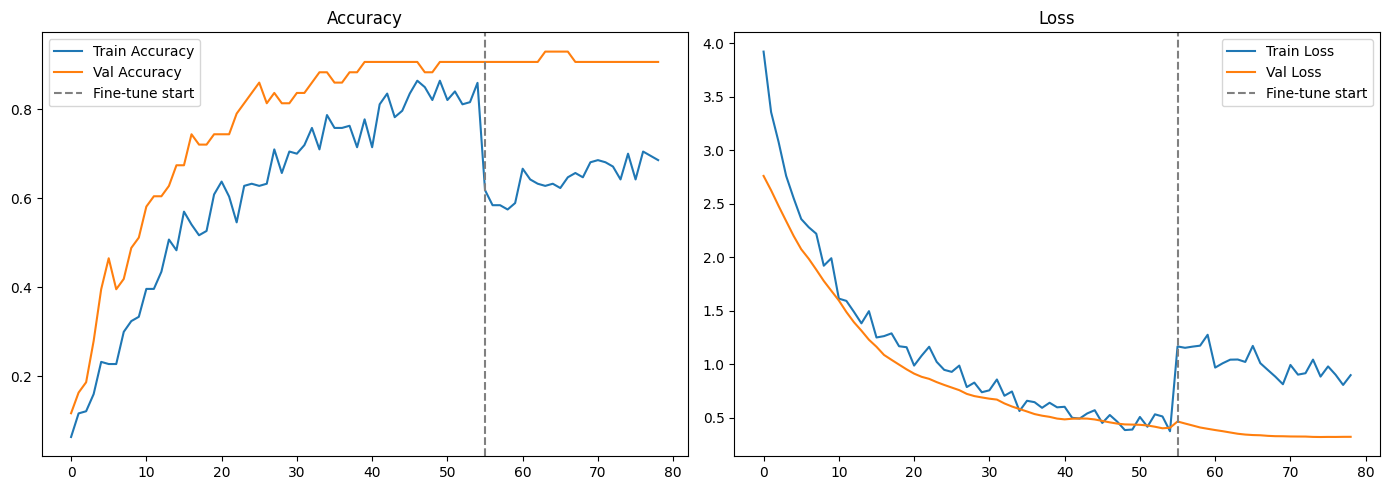


Final Summary:
  Total classes    : 16
  Total images     : 250
  Best val_accuracy: 0.9302
  TFLite size      : 11.47 MB
  Output dir       : /content/drive/My Drive/sugar_checker_data_V2/model_output


In [41]:
import matplotlib.pyplot as plt

# Combine history
acc     = history_1.history['accuracy']     + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss    = history_1.history['loss']         + history_2.history['loss']
val_loss= history_1.history['val_loss']     + history_2.history['val_loss']

epochs_range = range(len(acc))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc,     label='Train Accuracy')
axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
axes[0].axvline(len(history_1.history['accuracy']), color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, loss,     label='Train Loss')
axes[1].plot(epochs_range, val_loss, label='Val Loss')
axes[1].axvline(len(history_1.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150)
plt.show()

print('\nFinal Summary:')
print('=' * 50)
print(f'  Total classes    : {NUM_CLASSES}')
print(f'  Total images     : {TOTAL_IMAGES}')
print(f'  Best val_accuracy: {max(val_acc):.4f}')
print(f'  TFLite size      : {os.path.getsize(TFLITE_PATH)/1024/1024:.2f} MB')
print(f'  Output dir       : {OUTPUT_DIR}')
print('=' * 50)

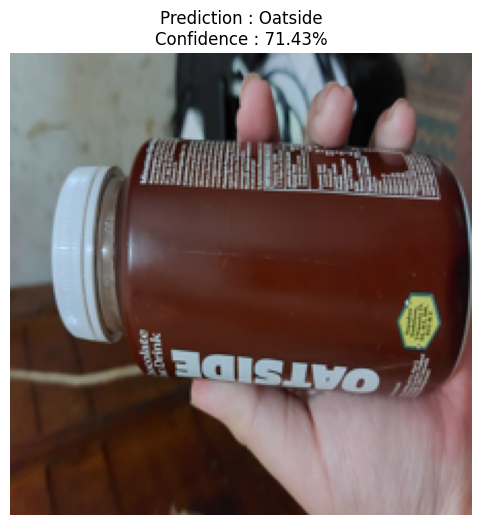

Medium confidence (71.43%) — Likely: Oatside

Top 3 predictions:
  1. Oatside                   71.43%
  2. cokelat_delfi             12.73%
  3. Adem_Sari                 4.34%


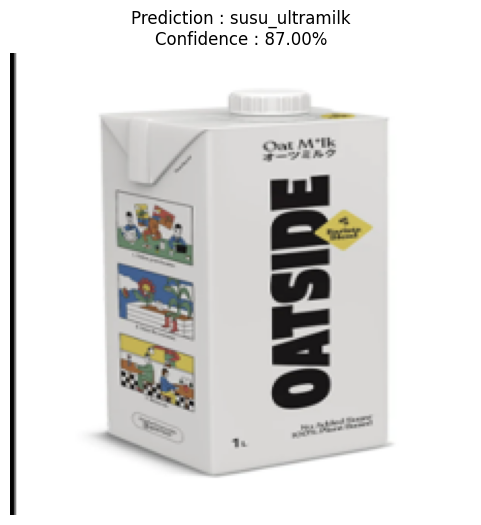

Medium confidence (87.00%) — Likely: susu_ultramilk

Top 3 predictions:
  1. susu_ultramilk            87.00%
  2. Indomilk                  3.71%
  3. Nola                      2.59%


In [46]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. Model & Image Path Configuration
model_path    = '/content/drive/My Drive/sugar_checker_data_V2/model_output/sugar_checker.tflite'
image_path    = '/content/drive/My Drive/20260414_003534.jpg'
image_path_2  = '/content/drive/My Drive/Screenshot 2026-04-14 at 00.39.08.png'

# 2. Load TFLite Model
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Class Labels (must match training order exactly)
json_path = '/content/drive/My Drive/sugar_checker_data_V2/model_output/labels.json'

with open(json_path, 'r') as f:
    label_map = json.load(f)

labels = [label_map[str(i)] for i in range(len(label_map))]

# 4. Inference Function
def run_inference(img_path):
    if not os.path.exists(img_path):
        print(f'Image not found: {img_path}')
        return

    # Load & preprocess (resize to 224x224, normalize to 0-1)
    img         = Image.open(img_path).convert('RGB')
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized, dtype=np.float32)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()

    output_data = interpreter.get_tensor(output_details[0]['index'])
    results     = np.squeeze(output_data)

    top_index  = results.argmax()
    confidence = results[top_index] * 100

    # Display image & result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title(f'Prediction : {labels[top_index]}\nConfidence : {confidence:.2f}%')
    plt.show()

    if confidence > 90:
        print(f'High confidence ({confidence:.2f}%) — Predicted: {labels[top_index]}')
    elif confidence > 60:
        print(f'Medium confidence ({confidence:.2f}%) — Likely: {labels[top_index]}')
    else:
        print(f'Low confidence ({confidence:.2f}%) — Uncertain, possibly: {labels[top_index]}')

    # Show top 3 predictions
    top3_idx = results.argsort()[::-1][:3]
    print('\nTop 3 predictions:')
    for i, idx in enumerate(top3_idx):
        print(f'  {i+1}. {labels[idx]:<25} {results[idx]*100:.2f}%')

# Run
run_inference(image_path)
run_inference(image_path_2)